In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

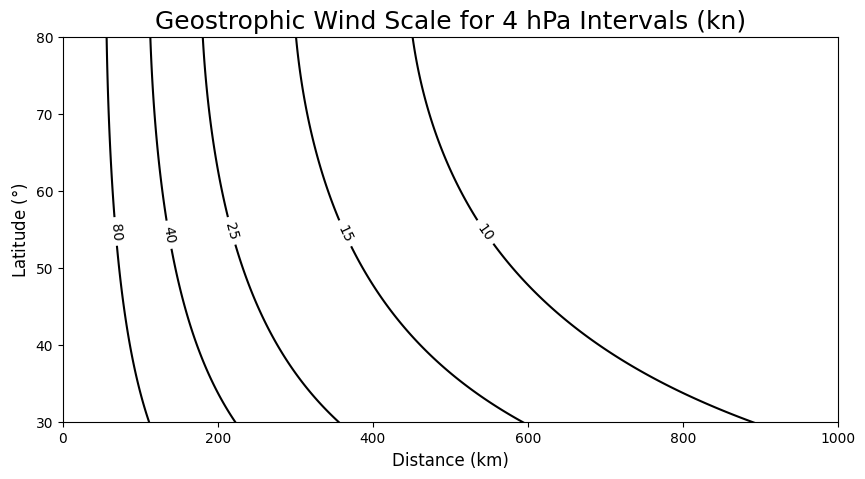

In [2]:
# geostrophic wind nomogram
V_knots = np.array([10, 15, 25, 40, 80])
V_ms = V_knots / 1.94384

Delta_P = 400
rho = 1.2
Omega = 7.292e-5

latitudes = np.linspace(29, 81, 1000)
distances = np.linspace(0, 1e6, 1000)

D, L = np.meshgrid(distances, latitudes)
with np.errstate(divide='ignore', invalid='ignore'):
    V_g = Delta_P / (2 * Omega * np.sin(np.radians(L)) * rho * D)

positions = [(1e5,55), (1.75e5,55), (2.25e5,55), (3.75e5,55), (5.5e5,55)]

plt.figure(figsize=(10, 5))
speeds = plt.contour(D, L, V_g, levels=V_ms, colors='black')
plt.clabel(speeds, manual=positions, fontsize=10, fmt=lambda v: f'{1.94384*v:.0f}')

ax = plt.gca()
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f'{x/1e3:g}')
)

plt.ylim(30, 80)

plt.title('Geostrophic Wind Scale for 4 hPa Intervals (kn)', fontsize=18)
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel(r'Latitude ($\degree$)', fontsize=12)

# plt.savefig('geostrophic_wind.png', dpi=300)

plt.show();